In [1]:
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib.lines import Line2D

pd.options.mode.chained_assignment = None
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('source/FReDA4.csv')
df["Group4"] = None

In [3]:
# Satisfied
df.loc[df['Group3'] == 'Couple Satisfaction', 'Group4'] = 'Couple Satisfaction'

# Deprived groups
df.loc[df['Group1'] == 'SubGroup-DeprivedBoth', 'Group4'] = 'Deprived_Both'
df.loc[df['Group1'] == 'SubGroup-DeprivedMe', 'Group4'] = 'Deprived_Me'
df.loc[df['Group1'] == 'SubGroup-DeprivedPartner', 'Group4'] = 'Deprived_Partner'
#
# Oversaturated groups
df.loc[df['Group1'] == 'SubGroup-OversaturatedBoth', 'Group4'] = 'Oversaturated_Both'
df.loc[df['Group1'] == 'SubGroup-OversaturatedMe', 'Group4'] = 'Oversaturated_Me'
df.loc[df['Group1'] == 'SubGroup-OversaturatedPartner', 'Group4'] = 'Oversaturated_Partner'

df.loc[df['Group3'] == 'Couple Mixed', 'Group4'] = 'Mixed couple'

In [4]:
df = df.rename(columns={
    'Relationship Satisfaction': 'Relationship_Satisfaction',
    'Relationship Length (years)': 'Relationship_Length_years',

    'Work Status': 'Work_Status',

    'Self-esteem': 'Self_esteem',
    'Life Satisfaction': 'Life_Satisfaction',

    'Relationship Sex': 'Relationship_Sex',
    'Relationship Length': 'Relationship_Length',
    'Age difference': 'Age_Difference',
    'Communication Quality': 'Communication_Quality',
    'Conflict Management': 'Conflict_Management'
})

In [5]:
mask1 = (
    df.groupby('CoupleId')['Frequency_F']
    .nunique()
    .eq(1)
)

mask2 = (
    df.groupby('CoupleId')['Desire_F']
    .nunique()
    .eq(1)
)

df['Match_Frequency'] = df['CoupleId'].map(
    lambda cid: 'Aligned' if mask1.get(cid, False) else 'Misaligned'
)
df['Match_Frequency_n'] = df['CoupleId'].map(
    lambda cid: 1 if mask1.get(cid, False) else 0
)

df['Match_Desire'] = df['CoupleId'].map(
    lambda cid: 'Aligned' if mask2.get(cid, False) else 'Misaligned'
)

df['Match_Desire_n'] = df['CoupleId'].map(
    lambda cid: 1 if mask2.get(cid, False) else 0
)

In [6]:
analysis_cols = [
   'Sex',
    'Age',
    'Work_Status',
    'Education',
    'Urbanization',

    'Extraversion',
    'Agreeableness',
    'Conscientiousness',
    'Openness',
    'Neuroticism',
    'Conservatism',
    'Religiosity',

    'Depressiveness',
    'Loneliness',
    'Self_esteem',
    'Life_Satisfaction',
    'Health',

    'Relationship_Sex',
    'Relationship_Length',
    'Age_Difference',
    'Married',
    'Cohabitation',
    'Kids',
    'Communication_Quality',
    'Relationship_Satisfaction',
    'Conflict_Management',
]

# df_clean = df[analysis_cols].dropna()

In [7]:
potential_predictors = analysis_cols
significant_predictors_f = []

In [8]:
for var in potential_predictors:
    formula = f"Match_Frequency_n ~ {var}"

    model = smf.gee(formula,
                    groups=df['CoupleId'],
                    data=df,
                    family=sm.families.Binomial()
                    ).fit()

    p_val = model.pvalues.iloc[1]
    if p_val < 0.05:
        significant_predictors_f.append(var)

print('Significant predictors found:', len(significant_predictors_f))
print(significant_predictors_f)

Significant predictors found: 7
['Age', 'Openness', 'Life_Satisfaction', 'Cohabitation', 'Communication_Quality', 'Relationship_Satisfaction', 'Conflict_Management']


In [9]:
final_formula = "Match_Frequency_n ~ " + " + ".join(significant_predictors_f)

# Using GEE with a Binomial family acts as a logistic regression that adjusts StdErrs for couples
final_model_f = smf.gee(final_formula,
                      groups=df['CoupleId'],
                      data=df,
                      family=sm.families.Binomial()
                      ).fit()

In [10]:
results_df = pd.DataFrame({
    'AOR': np.exp(final_model_f.params),
    'Lower CI': np.exp(final_model_f.conf_int()[0]),
    'Upper CI': np.exp(final_model_f.conf_int()[1]),
    'p-value': final_model_f.pvalues
})

In [11]:
# 1. Create a dictionary to rename the index rows directly
rename_dict = {
    'Self_esteem': 'Self Esteem',
    'Work_Status': 'Work Status',
    'Life_Satisfaction': 'Life Satisfaction',
    'Conflict_Management': 'Conflict Management',
    'Relationship_Length': 'Relationship Length',
    'Relationship_Satisfaction': 'Relationship Satisfaction',
    'Communication_Quality': 'Communication Quality'
}

results_df = results_df.rename(index=rename_dict)
results_df = results_df.reset_index().rename(columns={'index': 'Variable'})

results_df["err_lower"] = results_df["AOR"] - results_df["Lower CI"]
results_df["err_upper"] = results_df["Upper CI"] - results_df["AOR"]

In [12]:
plot_df = results_df.sort_values('AOR', ascending=True).reset_index(drop=True)
plot_df = plot_df.drop([0]).reset_index(drop=True)

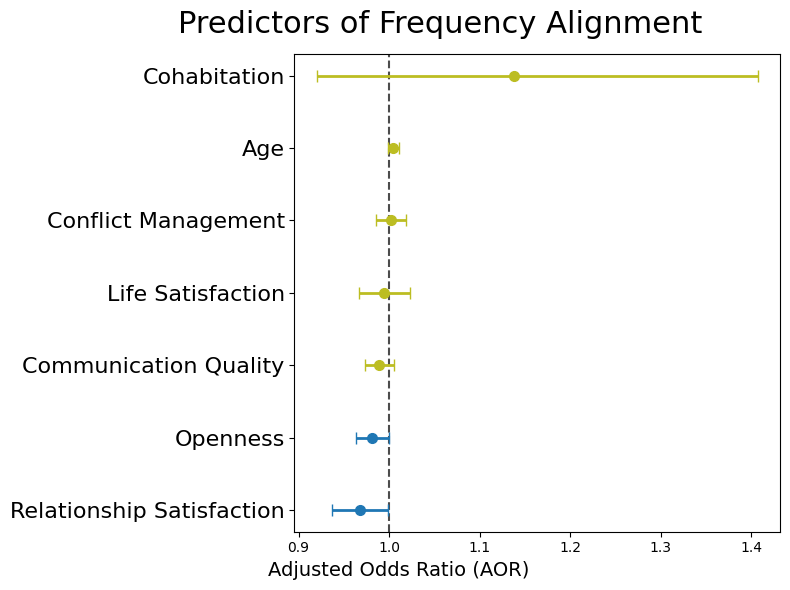

In [13]:
# 2. Set up the plot aesthetics
plt.figure(figsize=(8, 6))
plt.style.use('default')

# 3. Create colors based on significance (p < 0.05)
colors = ['#1f77b4' if p < 0.05 else '#bcbd22' for p in plot_df['p-value']]

for idx, (i, row) in enumerate(plot_df.iterrows()):
    plt.errorbar(
        x=row['AOR'],
        y=i,
        xerr=[[row['err_lower']], [row['err_upper']]],
        fmt='o',
        color=colors[idx],
        ecolor=colors[idx],
        capsize=4,
        markersize=7,
        linewidth=2
    )

plt.axvline(x=1.0, color='black', linestyle='--', alpha=0.7, zorder=0)

plt.yticks(range(len(plot_df)), plot_df['Variable'], fontsize=16)
plt.xlabel(
    "Adjusted Odds Ratio (AOR)",
    x=0.215,
    ha='center',
    fontsize=14)

plt.title("Predictors of Frequency Alignment", fontsize=22,
          pad=15, loc='center', x = 0.3)

custom_lines = [Line2D([0], [0], color='#1f77b4', lw=3, marker='o'),
                Line2D([0], [0], color='#bcbd22', lw=3, marker='o')]
# plt.legend(custom_lines, ['Significant (p < .05)', 'Not Significant'], loc='lower right', fontsize=16)
plt.tight_layout()

# plt.savefig("output/img/alignment/frequency.png",dpi=300, bbox_inches='tight')
plt.show()